In [ ]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

# Modeling

from sklearn.tree import DecisionTreeRegressor

# Metrics

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/processed_data.xlsx')

# Train Test Split

In [ ]:
X_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_train_cost_prediction.xlsx')
y_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_train_cost_prediction.xlsx')
X_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_test_cost_prediction.xlsx')
y_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_test_cost_prediction.xlsx')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (196, 10)
X_test shape: (49, 10)
y_train shape: (196, 1)
y_test shape: (49, 1)


# Modeling

In [ ]:
best_params = {
'random_state':42
}

In [ ]:
def test_params(ModelClass, train_inputs, train_target, test_inputs, test_target, **params):
  model = ModelClass(**params).fit(train_inputs, train_target)

  train_rmse = root_mean_squared_error(model.predict(train_inputs), train_target)
  test_rmse = root_mean_squared_error(model.predict(test_inputs), test_target)
  return train_rmse, test_rmse

# testing and plotting

def test_param_and_plot(ModelClass, param_name, param_values, train_inputs, train_target, test_inputs, test_target, **other_params):
  train_errors = []
  test_errors = []

  param_values_list = list(param_values)

  for value in param_values_list:
    params = dict(other_params)
    params[param_name] = value
    train_rmse, test_rmse = test_params(ModelClass, train_inputs, train_target, test_inputs, test_target, **params)
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

  dataframe_for_plot = pd.DataFrame({
      'param_values': param_values_list,
      'Training': train_errors,
      'Testing': test_errors
  })

  fig = px.line(dataframe_for_plot,
                x='param_values',
                y=['Training', 'Testing'],
                title=f'Overfitting curve' + param_name,
                labels={'value': 'RMSE', 'param_values': param_name},
                markers=True)

  fig.update_layout(
      xaxis_title=param_name,
      yaxis_title='RMSE',
      legend_title='Metric'
  )
  fig.show()

max_depth

In [ ]:
test_param_and_plot(
    ModelClass=DecisionTreeRegressor,
    param_name='max_depth',
    param_values=range(1,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

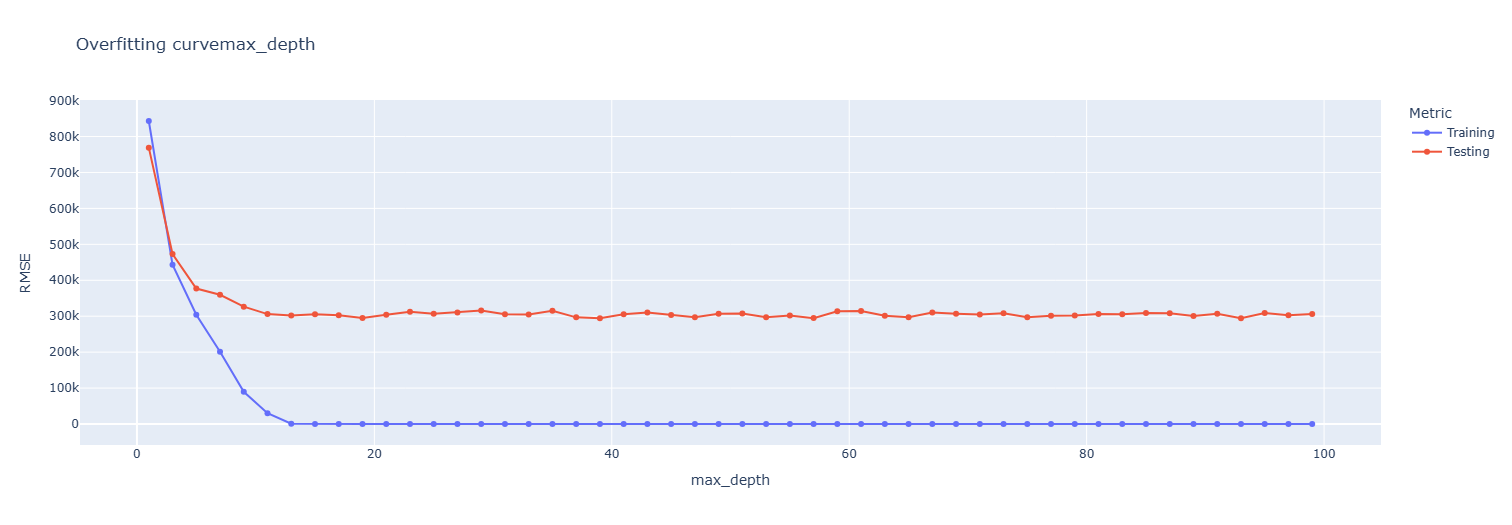

In [ ]:
best_params['max_depth'] = 5

min_samples_split

In [ ]:
test_param_and_plot(
    ModelClass=DecisionTreeRegressor,
    param_name='min_samples_split',
    param_values=range(2,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

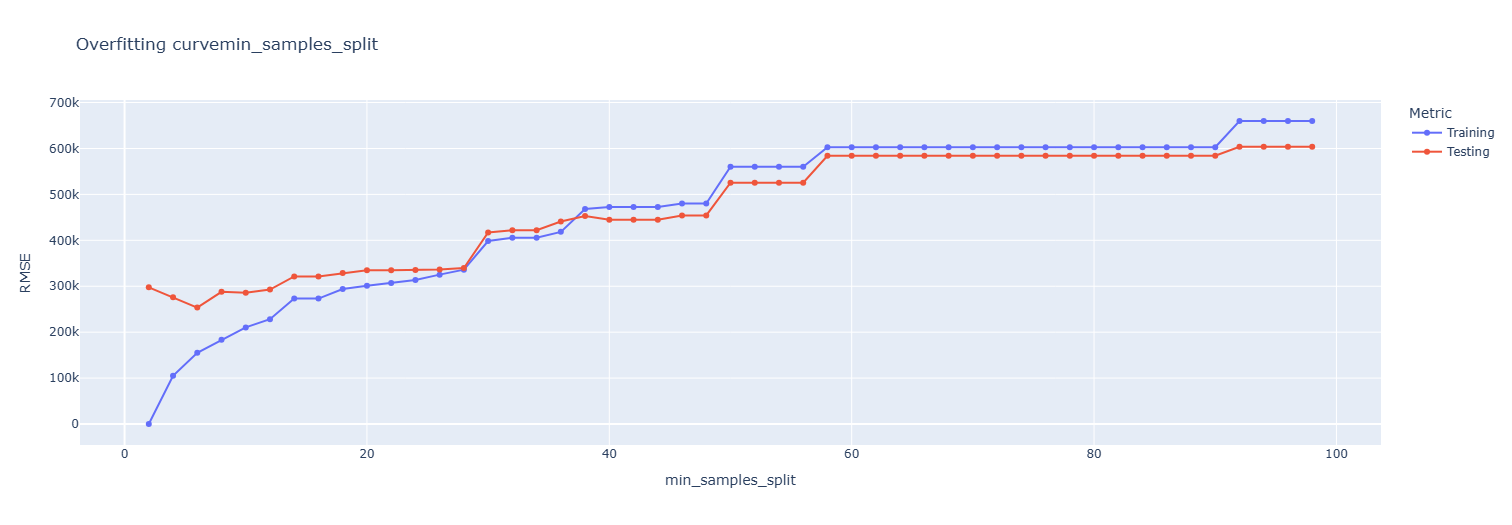

In [ ]:
best_params['min_samples_split'] = 28

min_samples_leaf

In [ ]:
test_param_and_plot(
    ModelClass=DecisionTreeRegressor,
    param_name='min_samples_leaf',
    param_values=range(1,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

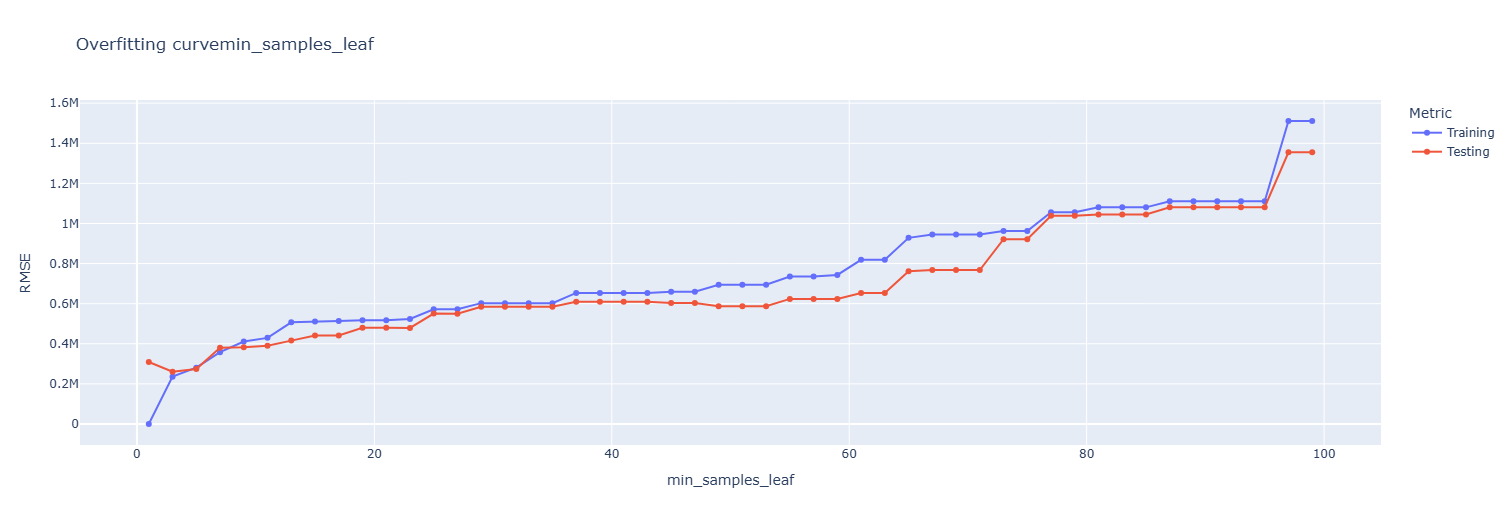

In [ ]:
best_params['min_samples_leaf'] = 3

min_weight_fraction

In [ ]:
test_param_and_plot(
    ModelClass=DecisionTreeRegressor,
    param_name='min_weight_fraction_leaf',
    param_values=np.arange(0,0.5,0.02),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

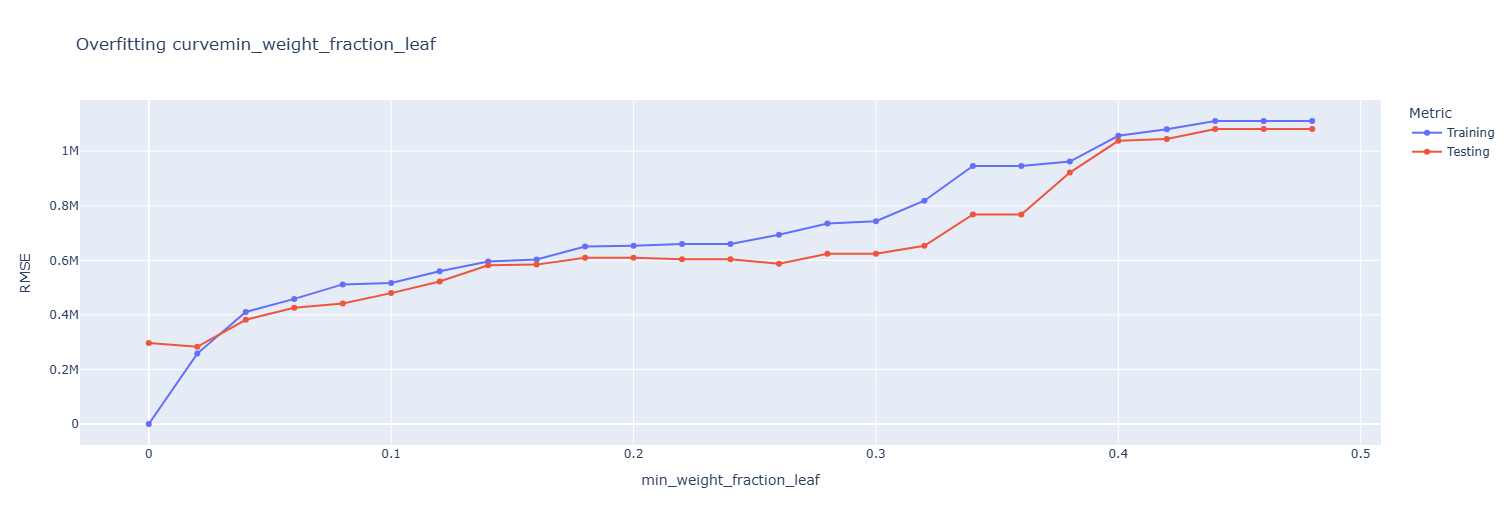

In [ ]:
best_params['min_weight_fraction_leaf'] = 0.02

FINAL PARAMETERS

In [ ]:
best_params

{'random_state': 42,
 'max_depth': 5,
 'min_samples_split': 28,
 'min_samples_leaf': 3,
 'min_weight_fraction_leaf': 0.02}

PREDICTIONS

In [ ]:
model_dtr = DecisionTreeRegressor(**best_params).fit(X_train, y_train)

dtr_pred = model_dtr.predict(X_test)

In [ ]:
def plot_regression_results(y_true, y_pred, title='Regression Predictions'):
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs. predicted values
    plt.scatter(y_true, y_pred, alpha=0.6, label='Actual vs. Predicted')

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction (y=x)')

    plt.title(title)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Calculate and print metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.4f}')
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'MAPE: {mape:.4f}')
    r2 = r2_score(y_true, y_pred)
    print(f'R2: {r2:.4f}')

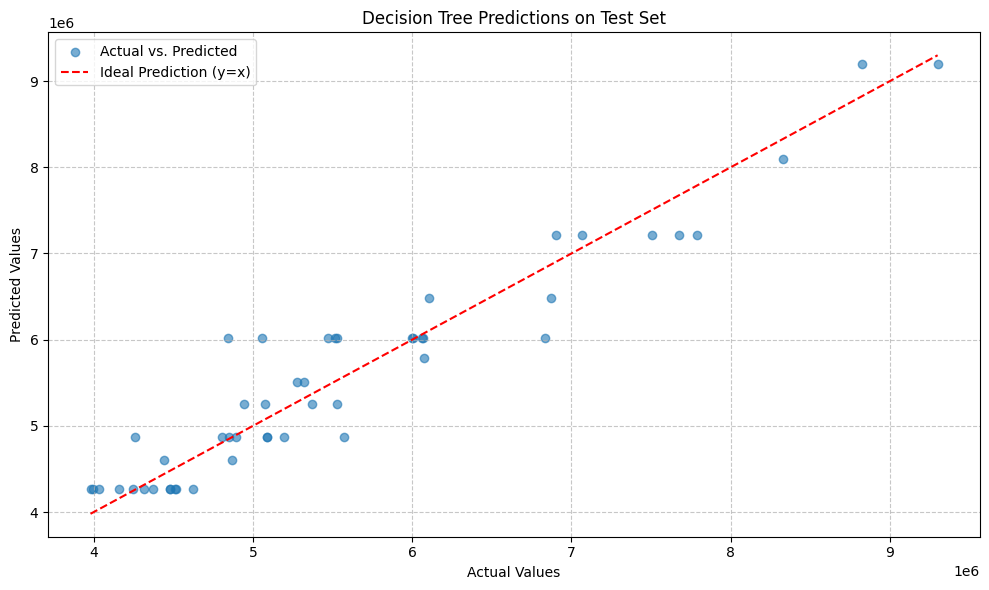

RMSE: 380775.9702
MAPE: 0.0542
R2: 0.9121


In [ ]:
plot_regression_results(y_test.values, dtr_pred, title='Decision Tree Predictions on Test Set')

# Residual Plot

In [ ]:
def residual_plot(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    residuals = y_true - y_pred

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.6
    )

    plt.axhline(y=0, color='r', linestyle='--')

    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

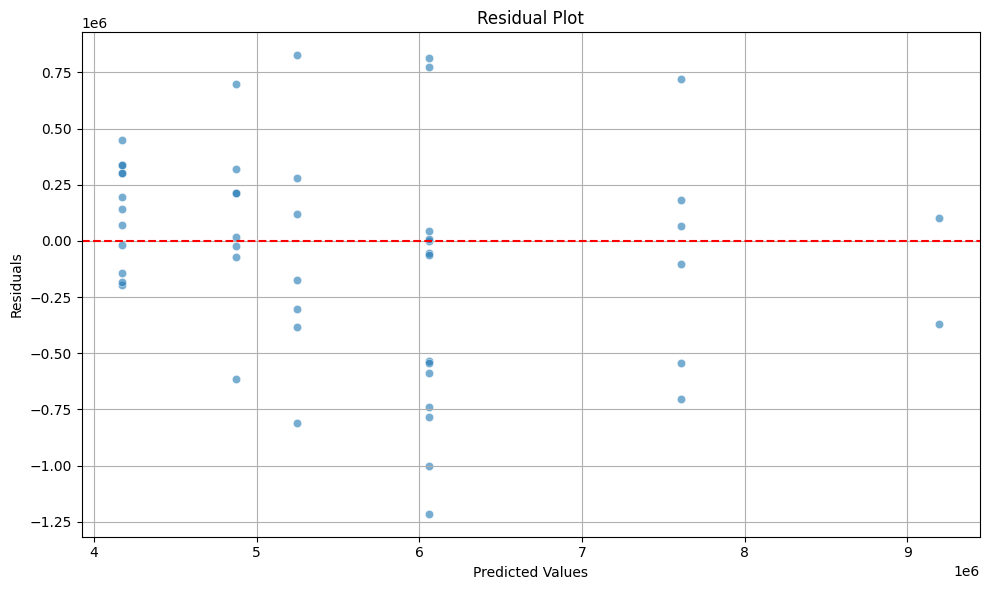

In [ ]:
residual_plot(y_test,dtr_pred)

# Feature Importance

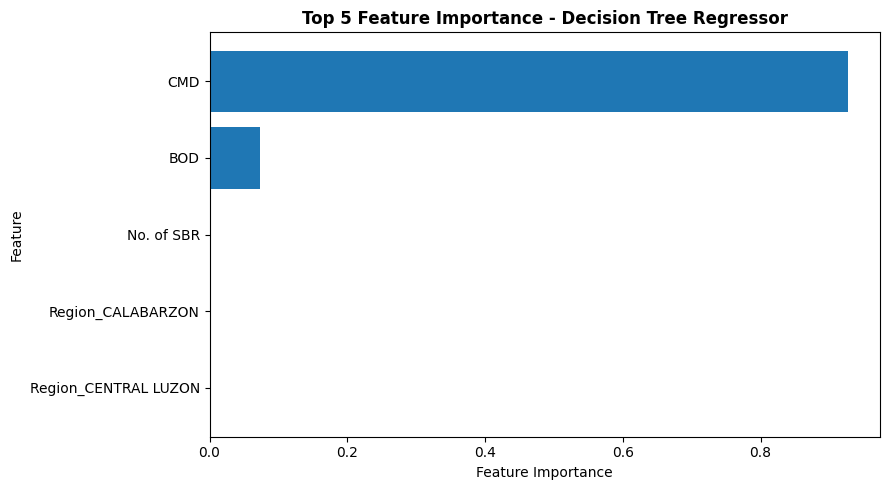

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_dtr.feature_importances_
}).sort_values('Importance', ascending=False).head(5)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 5 Feature Importance - Decision Tree Regressor',
          fontweight='bold')

plt.tight_layout()
plt.show()